# DBI scheduling: simulated annealing (SA)

While exploring the efficacy of the BHMM method for double bracket iterations, where a fixed diagonal operator is used through out the iterations, we notice that the scheduling method plays a significant role in whether the diagonalization gets stuck. Hence, we employ other optimizing methods for scheduling the optimal rotation duration.


The options we consider include:

1. Adapative grid search. Given the loss function and search space, the algorithm runs through the search space like grid search, arriving at a minimum value. Then, another grid search with half the grid size is conducted, finding another minimum. If the 2 minima coincide, we accept it as the global minimum. Otherwise, run grid size by half again, until we find coinciding minimum. This search method does not guarantee finding the first minimum value. A modification can be made, e.g. set tolerance value, in a comparison, accept the one nearer to origin if difference is within tolerence.

2. Golden section search -> very likely to miss a minimum outside the section -> abandon.

3. Simulated annealing (SA).

In [1]:
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math
import seaborn as sns

from qibo import hamiltonians, set_backend
from qibo.hamiltonians import Hamiltonian, SymbolicHamiltonian
from qibo.quantum_info import random_hermitian
from qibo.models.dbi.double_bracket import DoubleBracketGeneratorType, DoubleBracketScheduling, DoubleBracketIteration
from qibo.models.dbi.utils import *

In [2]:
def visualize_matrix(matrix, title=""):
    """Visualize hamiltonian in a heatmap form."""
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    try:
        im = ax.imshow(np.absolute(matrix), cmap="inferno")
    except TypeError:
        im = ax.imshow(np.absolute(matrix.get()), cmap="inferno")
    fig.colorbar(im, ax=ax)

# General initialization

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
[Qibo 0.2.5|INFO|2024-03-14 10:39:19]: Using qibojit (numba) backend on /CPU:0


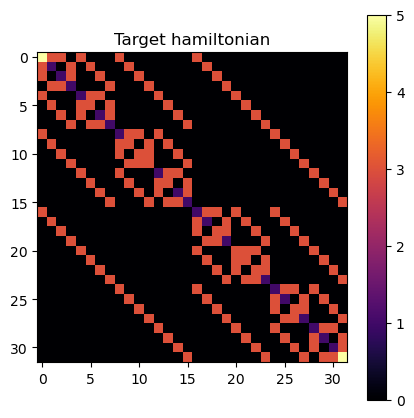

In [3]:
# set the qibo backend (we suggest qibojit if N >= 20)
set_backend("qibojit", "numba")

# hamiltonian parameters
nqubits = 5
h = 3

# define the hamiltonian
H_TFIM = hamiltonians.TFIM(nqubits=nqubits, h=h)

# vosualize the matrix
visualize_matrix(H_TFIM.matrix, title="Target hamiltonian")

In [207]:
def test_BHMM(H:Hamiltonian, NSTEPS, d_list, scheduling, **kwargs):
    num_test = len(d_list)
    mode = DoubleBracketGeneratorType.single_commutator
    dbi_list = [DoubleBracketIteration(deepcopy(H), mode=mode)] * num_test
    loss_list = np.zeros((num_test, NSTEPS+1))
    s_list = np.zeros((num_test, NSTEPS+1))
    for i in range(NSTEPS+1):
        for j,d in enumerate(d_list):
            # Initial values
            if i == 0:
                loss_list[j][i] = dbi_list[j].off_diagonal_norm
            else:
                step = scheduling(dbi_list[j], d=d, **kwargs)
                dbi_list[j](step=step, d=d)
                loss_list[j][i] = dbi_list[j].off_diagonal_norm
                s_list[j][i] = step
    return loss_list, s_list
    
def plot_histories_iter(histories, labels,save_fig=False, title=''):
    """Plot off-diagonal norm histories over a sequential evolution."""
    plt.figure(figsize=(5,5*6/8))
    for i, (h, l) in enumerate(zip(histories, labels)):
        plt.plot(h, lw=2, label=l, marker='.')
    plt.legend()
    plt.xlabel("Iterations")
    plt.ylabel(r"$\| \sigma(\hat{H}) \|^2$")
    plt.title("Loss function histories")
    plt.grid(True)
    if save_fig:
        plt.savefig(title, bbox_inches="tight")
    plt.show()

def step_to_plot(s_list):
    NSTEPSp1 = len(s_list)
    return [sum(s_list[:i+1]) for i in range(NSTEPSp1)]

def plot_histories_step(histories, s_list, labels, save_fig=False, title=''):
    """Plot off-diagonal norm histories over a sequential evolution with step duration as the horizontal axis."""
    plt.figure(figsize=(5,5*6/8))
    for i, (h, l) in enumerate(zip(histories, labels)):
        s_plot = step_to_plot(s_list[i])
        plt.plot(s_plot, h, lw=2, label=l, marker='o')
    plt.legend()
    plt.xlabel("Evolution duration")
    plt.ylabel(r"$\| \sigma(\hat{H}) \|^2$")
    plt.title("Loss function histories")
    plt.grid(True)
    if save_fig:
        plt.savefig(title, bbox_inches="tight")
    plt.show()

def normalize_matrix(matrix):
    # Restrict the maximum abs value of an array to 1
    return matrix/np.max(np.abs(matrix))

# Simulated annealing

In [208]:
def step_annealing(dbi_object, d, initial_s=None, step_min=1e-5, step_max=1, s_jump_range=None, s_jump_range_divident=5, initial_temp=1, cooling_rate=0.85, min_temp=1e-5, max_iter=200, verbose=False):
    if initial_s is None:
        initial_s,_ = dbi_object.polynomial_step(d=d, n=4)
    if s_jump_range is None:
        s_jump_range = (step_max - step_min)/s_jump_range_divident
    current_s = initial_s
    current_loss = dbi_object.loss(d=d, step=current_s)
    if verbose:
        print("initial_s", current_s)
        print("initial loss", current_loss)
    temp = initial_temp
    
    for _ in range(max_iter):
        candidate_s = max(step_min, min(current_s + np.random.uniform(-s_jump_range, s_jump_range, step_max)))
        candidate_loss = dbi_object.loss(d=d, step=candidate_s)
        
        # Calculate change in loss
        delta_loss = candidate_loss - current_loss
        
        # Determine if the candidate solution is an improvement
        if delta_loss < 0 or np.random.rand() < math.exp(-delta_loss / temp):
            current_s = candidate_s
            current_loss = candidate_loss
            if verbose:
                print(f"Iter {_} s {candidate_s} accepted with loss {candidate_loss} and prob {math.exp(-delta_loss / temp)} at temp {temp}")
        elif verbose:
            print(f"Iter {_} s {candidate_s} loss {candidate_loss} not accepted with prob {math.exp(-delta_loss / temp)}")
        # Cool down
        temp *= cooling_rate
        if temp < min_temp:
            break
    
    return current_s

## Min-max with eigen matrix

In [209]:
# generate min-max operator and eigen matrix
# min-max
min_max = diagonal_min_max(H_TFIM.matrix)
# eigen
eigen = np.diag(np.linalg.eigvalsh(H_TFIM.matrix))
# compare the 2
diff = np.diag(min_max) - np.diag(eigen)
normalize_min_max = normalize_matrix(min_max)
normalize_eigen = normalize_matrix(eigen)

In [210]:
# Test for TFIM with d (min-max and eigen)
NSTEPS = 5
d_list = [min_max, normalize_min_max, eigen, normalize_eigen]
d_names = ['min-max', 'normalize_min-max', 'eigen', 'normalize_eigen']
loss_list, s_list = test_BHMM(H_TFIM, NSTEPS=NSTEPS, d_list=d_list, scheduling=step_annealing, max_iter=30)

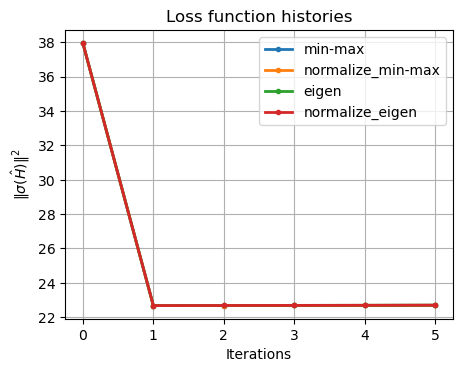

In [211]:
plot_histories_iter(loss_list, d_names)

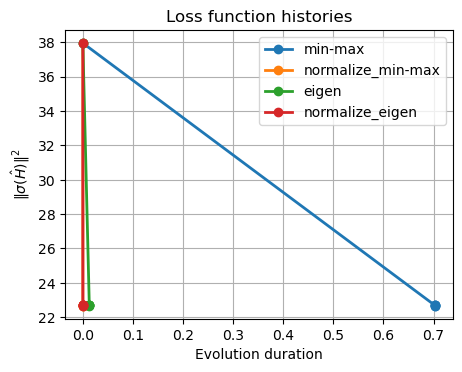

In [212]:
plot_histories_step(loss_list, s_list, d_names)

In [213]:
# Random hamiltonian
seed = 1
H_random = Hamiltonian(nqubits=nqubits, matrix=random_hermitian(2**nqubits, seed=seed))
# generate min-max operator and eigen matrix
# min-max
min_max = diagonal_min_max(H_random.matrix)
# eigen
eigen = np.diag(np.linalg.eigvalsh(H_random.matrix))
# compare the 2
diff = np.diag(min_max) - np.diag(eigen)
normalize_min_max = normalize_matrix(min_max)
normalize_eigen = normalize_matrix(eigen)

In [214]:
# Test for TFIM with d (min-max and eigen)
NSTEPS = 15
d_list = [min_max, normalize_min_max, eigen, normalize_eigen]
d_names = ['min-max', 'normalize_min-max', 'eigen', 'normalize_eigen']
loss_list, s_list = test_BHMM(H_random, NSTEPS=NSTEPS, d_list=d_list, scheduling=step_annealing, max_iter=30, initial_temp=1, verbose=False)

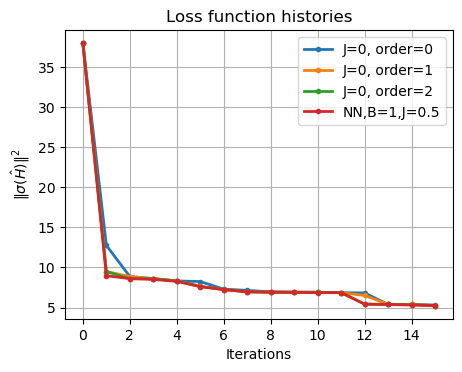

In [221]:
plot_histories_iter(loss_list, d_names, save_fig=True, title='Normalize_minmax_eigen.pdf')

Observations:

1. The same setting of SA scheduling (initial temp = 1, max_iter=300) works for the tested hamiltonians
2. As the diagonal operators scale with `normalization`, the optimal step duration is also scaled such that they perform similarly with and without normalization.

## Classical Ising model

Nearest neighbor Ising model: $j=i+1$

$D=\sum B_iZ_i + \sum J_{ij}Z_iZ_j$

Here we discuss two scenarios, where $J_{ij}$ equals 0 or non-zero.

In [216]:
# Generate diagonal operators

# Case 1: J=1
# Generate Z operators
Z_ops = generate_onsite_Z_ops(nqubits)
def B_order(nqubits, order, Z_ops):
    coef = np.array([(i+1)**order for i in range(nqubits)])
    return np.sum(coef.reshape(-1,1,1)*Z_ops, 0)

highest_order_test = 2
B_ops = [B_order(nqubits, order, Z_ops) for order in range(highest_order_test+1)]
B_normalize_ops = list(map(normalize_matrix, B_ops))

# Case 2: J\=0
# Function to generate operator strings
def generate_str_with_n_ops_nn(nqubits, num_Z, pauli_name):
    op_str = []
    for num in range(num_Z):
        pauli_neighbor = pauli_name * (num+1)
        op_str += [''.join(pauli_neighbor if i in positions else 'I' for i in range(nqubits-num)) 
            for positions in combinations(range(nqubits-num), 1)]
    return op_str
# test
op_names = generate_str_with_n_ops_nn(nqubits,2,"Z")
# print(op_names)
# len(op_names)== 2*nqubits-1
# generate operators
ising_ops = [SymbolicHamiltonian(str_to_symbolic(op_name)).dense.matrix for op_name in op_names]
# dictionary
op_dict = dict(zip(op_names, ising_ops))

B = 1
J = 0.5
constant_coef = np.array([B]*nqubits + [J]*(nqubits-1))
constant_op = np.sum(constant_coef.reshape(-1,1,1)*ising_ops,0)

[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.5|WARNING|2024-03-14 14:39:13]: Calculating the dens

/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pethidine/anaconda3/envs/DBF_qibo/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Sorted diagonal entries')

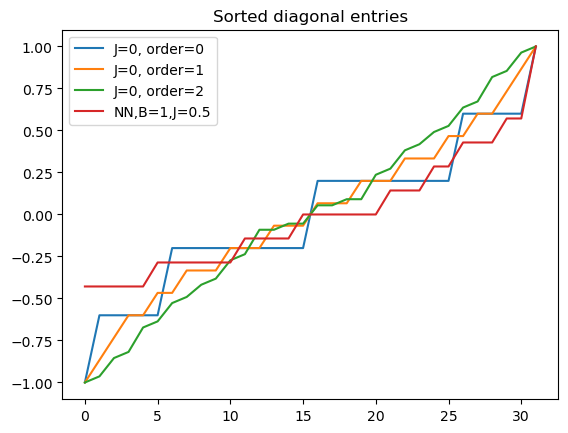

In [217]:
# visualizing the matrices: degeneracy
sort_B_ops = [np.sort(np.diag(B_op)) for B_op in B_normalize_ops]
for order, sort_B_op in enumerate(sort_B_ops):
    plt.plot(sort_B_op, label=f'J=0, order={order}')
plt.plot(np.sort(np.diag(normalize_matrix(constant_op))),  label=f'NN,B={B},J={J}')
plt.legend()
plt.title('Sorted diagonal entries')

In [218]:
d_list = B_ops
d_list.append(constant_op)
d_names = [f'J=0, order={order}' for order in range(highest_order_test+1)] + [f'NN,B={B},J={J}']
loss_list, s_list = test_BHMM(H_TFIM, NSTEPS=NSTEPS, d_list=d_list, scheduling=step_annealing, max_iter=30, initial_temp=1)

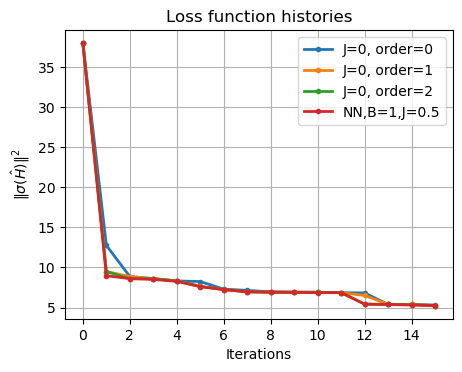

In [219]:
plot_histories_iter(loss_list, d_names)

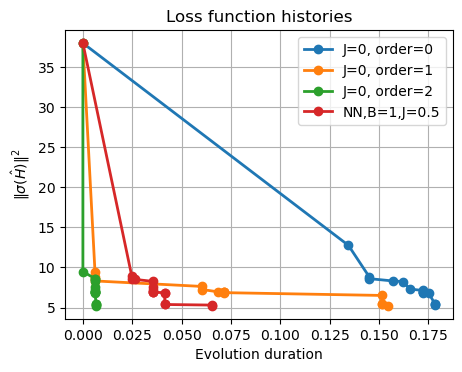

In [220]:
plot_histories_step(loss_list, s_list, d_names, save_fig=True, title='Ising_different_n.pdf')

### Random Hamiltonian

In [166]:
seed = 1
H_random = Hamiltonian(nqubits=nqubits, matrix=random_hermitian(2**nqubits, seed=seed))

In [167]:
loss_list, s_list = test_BHMM(H_random, NSTEPS=NSTEPS, d_list=d_list, scheduling=step_annealing, max_iter=30, initial_temp=1)

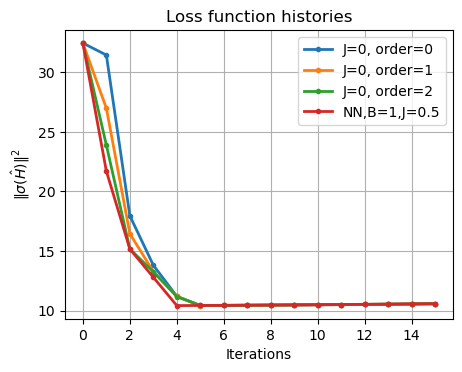

In [168]:
plot_histories_iter(loss_list, d_names)

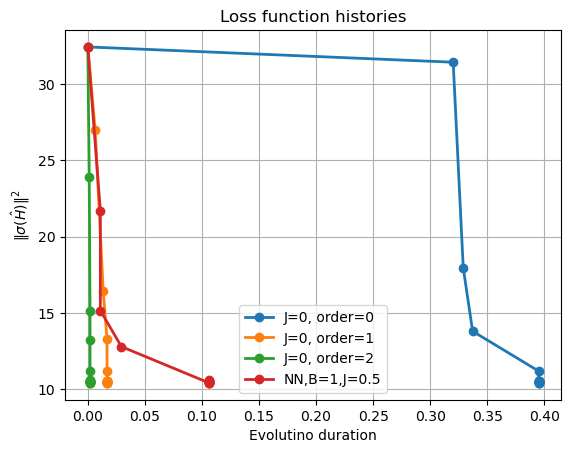

In [169]:
plot_histories_step(loss_list, s_list, d_names)

Observation:

1. From the above results we can infer that fixed diagonal operators can indeed diagonalize Hamiltonians as per MHH.

2. While the different order magnetic field operators, including the Ising model where nearest neighbor interaction is allowed, all lead to a similar level of diagonalization, the lesser the degeneracy, the faster is the diagonalization.

# Universality of the default setting?

We see that the default setting ,where `initial_temp=1` and `cooling_rate=0.8` which gives about 30 iterations before a search is complete, is sufficiently good for both TFIM and random Hamiltonians with `nqubits=5`. We wonder how universal is this setting, and how we can scale them as the system size changes?